## Let's use the different modes of the `make_multisite_classification` function

In [10]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from uniharmony import make_multisite_classification
from uniharmony._verbose import verbosity


sns.set_theme(style="whitegrid")
verbosity("warning")

## We will start with the function as default

X has 1000 examples and 10 features


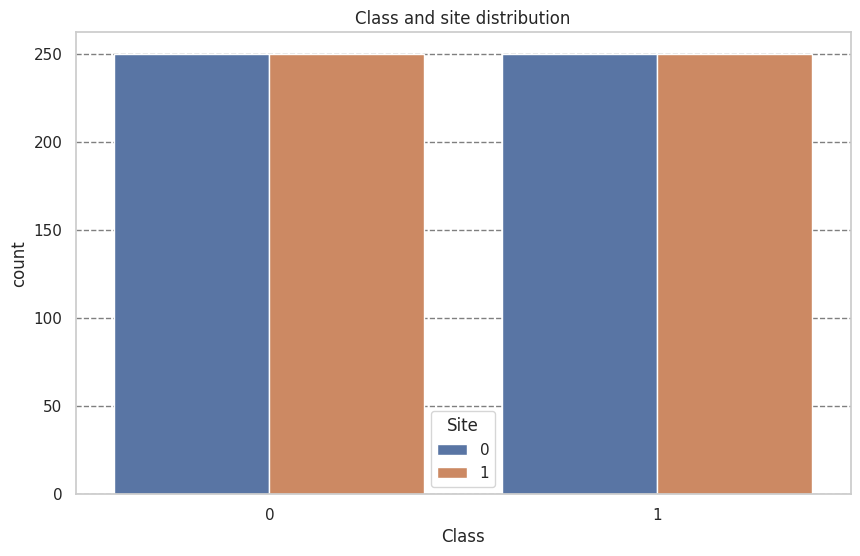

In [11]:
X, y, sites = make_multisite_classification()
df = pd.DataFrame({"Class": y, "Site": sites})
print(f"X has {X.shape[0]} examples and {X.shape[1]} features")

plt.figure(figsize=[10, 6])
plt.title("Class and site distribution")
sns.countplot(df, x="Class", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

Let's increase the number of sites. Note that the total number of samples is the same, but the distribution changed.

For n_sites 2, X has 1000 examples and 10 features
For n_sites 4, X has 1000 examples and 10 features
For n_sites 10, X has 1000 examples and 10 features


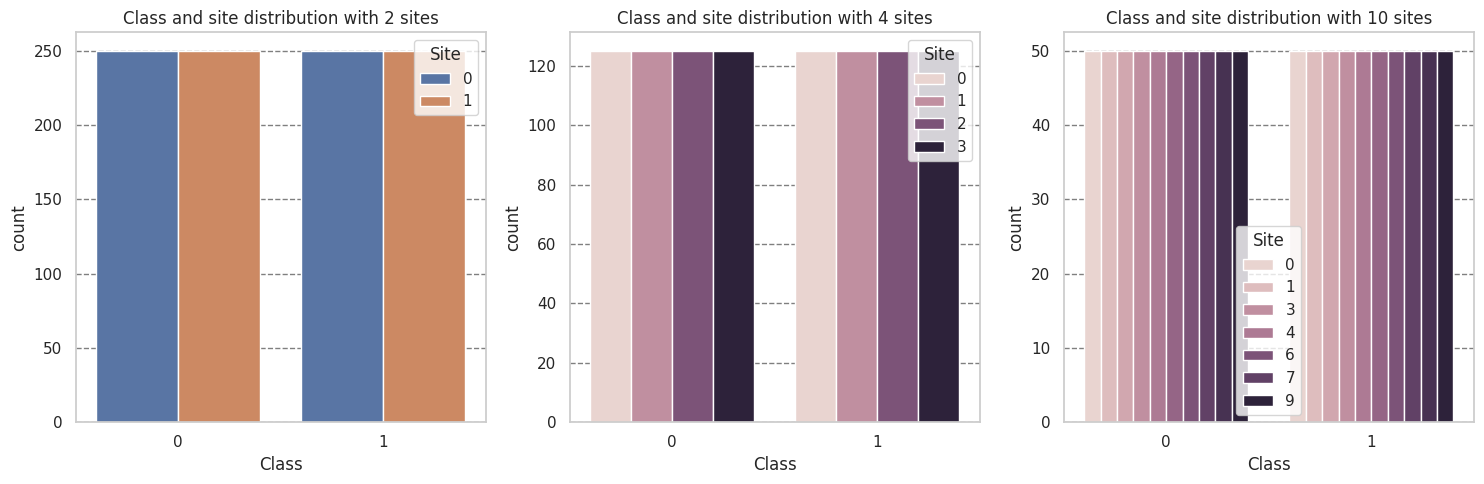

In [12]:
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, n_sites in enumerate([2, 4, 10]):
    X, y, sites = make_multisite_classification(n_sites=n_sites)
    print(f"For n_sites {n_sites}, X has {X.shape[0]} examples and {X.shape[1]} features")

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )
    sns.countplot(df_plot, x="Class", hue="Site", ax=axes[idx])
    plt.title("Class and site distribution")

    axes[idx].set_title(f"Class and site distribution with {n_sites} sites")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

For n_classes 2, X has 1000 examples and 10 features
For n_classes 4, X has 1000 examples and 10 features
For n_classes 10, X has 1000 examples and 10 features


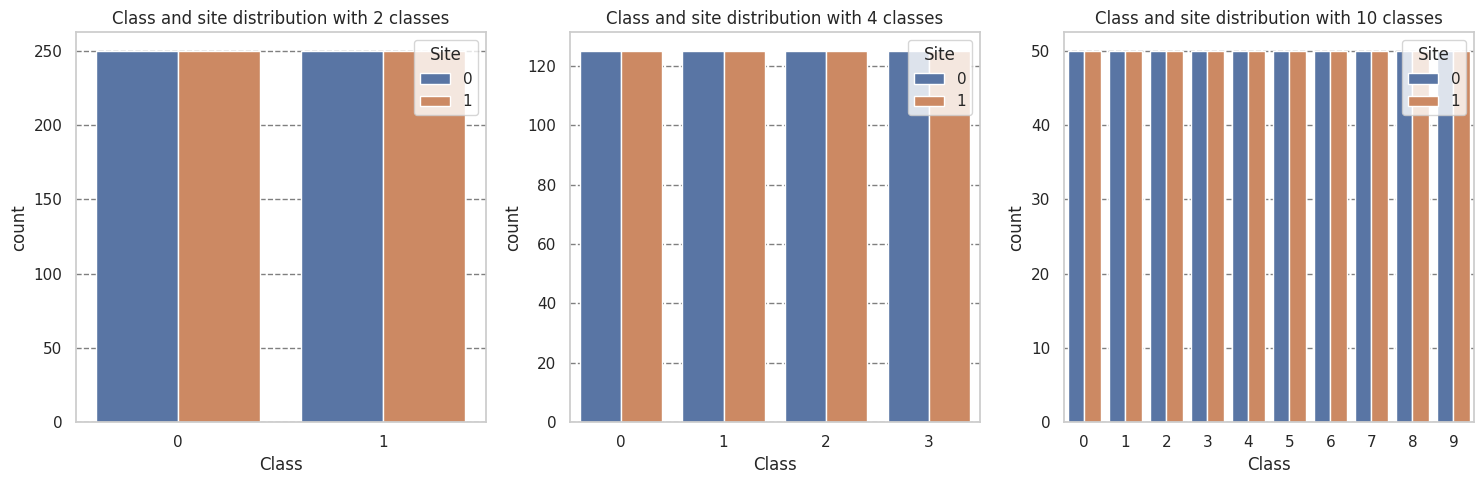

In [13]:
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, n_classes in enumerate([2, 4, 10]):
    X, y, sites = make_multisite_classification(n_classes=n_classes)
    print(f"For n_classes {n_classes}, X has {X.shape[0]} examples and {X.shape[1]} features")

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )
    sns.countplot(df_plot, x="Class", hue="Site", ax=axes[idx])
    axes[idx].set_title(f"Class and site distribution with {n_classes} classes")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

## Changing the class balance:
As default, the created problem is balanced accross sites, so all classes has the same number of examples in each site. 
We can control that using the `balance_per_site` of the function. 

For n_classes 10, X has 1000 examples and 10 features
For n_classes 10, X has 1000 examples and 10 features
For n_classes 10, X has 1000 examples and 10 features


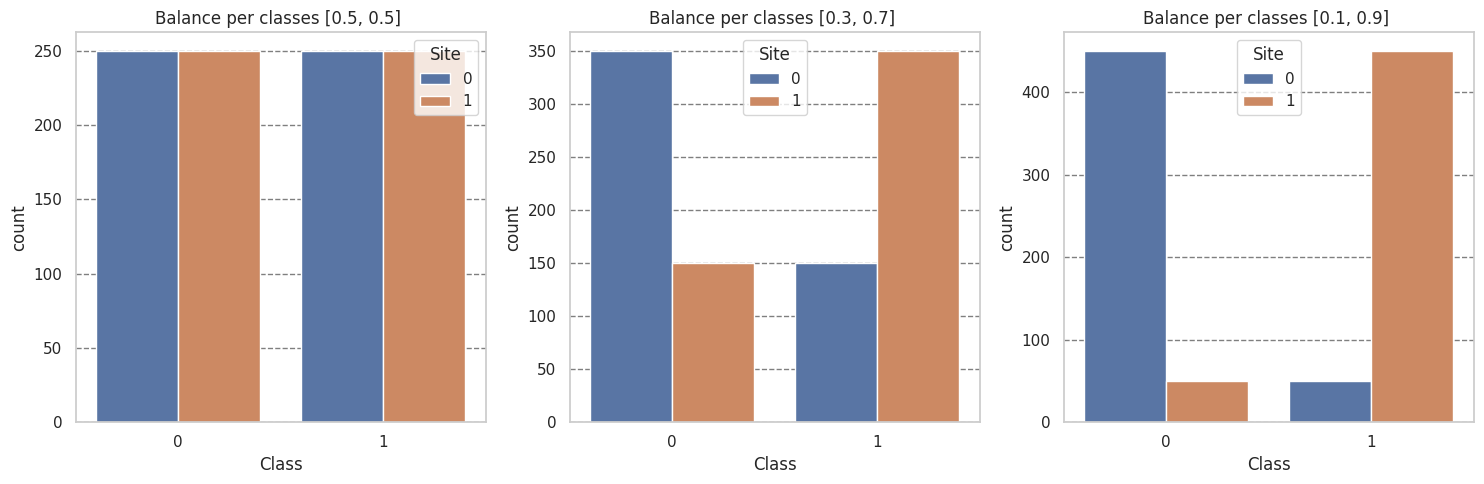

In [14]:
# In a binary classification problem, you need to set which
# proportion of class 1 is present in that site.
# Thus, the number of elements in the list must match the number of sites.
fig, axes = plt.subplots(1, 3, figsize=[15, 5])
balance_per_site_list = [[0.5, 0.5], [0.3, 0.7], [0.1, 0.9]]
for idx, balance_per_site in enumerate(balance_per_site_list):
    X, y, sites = make_multisite_classification(balance_per_site=balance_per_site)
    print(f"For n_classes {n_classes}, X has {X.shape[0]} examples and {X.shape[1]} features")

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )
    sns.countplot(df_plot, x="Class", hue="Site", ax=axes[idx])
    axes[idx].set_title(f"Balance per classes {balance_per_site} ")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

Now that we changed the balance, we have different occurence in different sites. Note that the total number of classes is still balanced, is the distribution accross sites that changed.

# Let's now see how the signal looks like

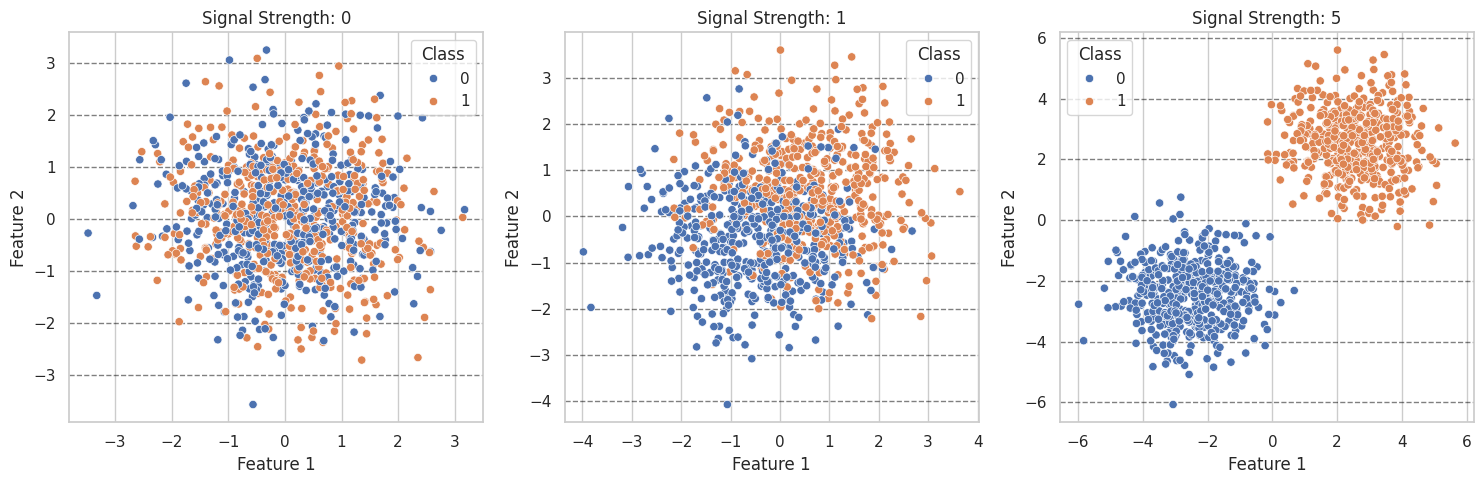

In [15]:
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, signal_st in enumerate([0, 1, 5]):
    X, y, sites = make_multisite_classification(
        n_features=2,
        signal_strength=signal_st,
        noise_strength=0,
        site_effect_strength=0,
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Class", ax=axes[idx])
    axes[idx].set_title(f"Signal Strength: {signal_st}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

### Effect of Site effect

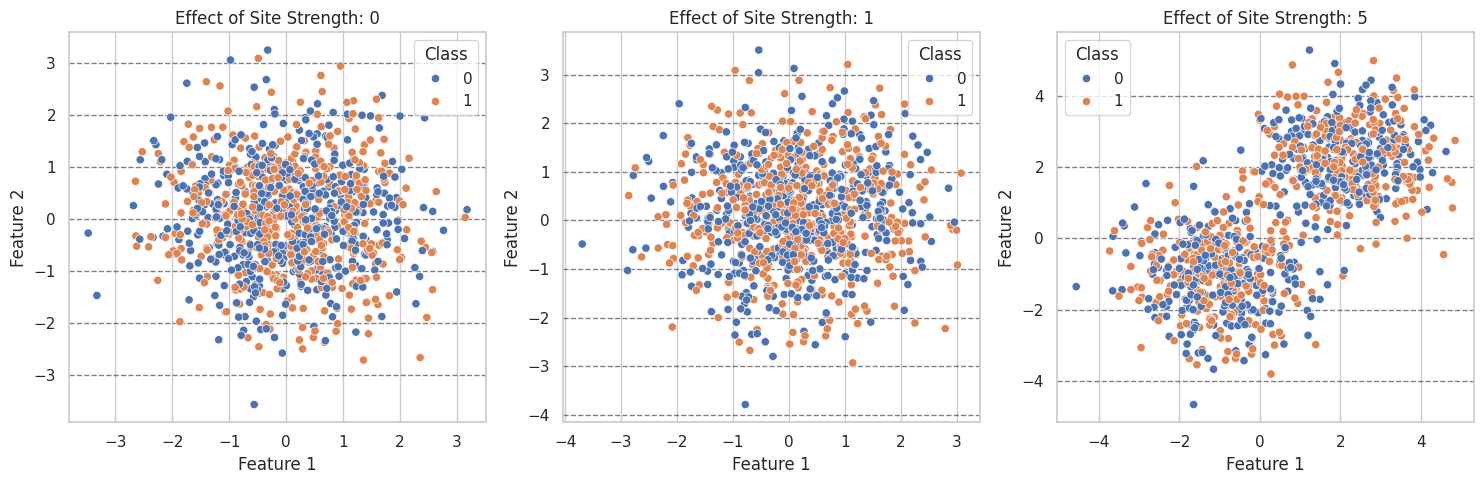

In [16]:
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, site_st in enumerate([0, 1, 5]):
    X, y, sites = make_multisite_classification(
        n_features=2,
        signal_strength=0,
        noise_strength=0,
        site_effect_strength=site_st,
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Class", ax=axes[idx])
    axes[idx].set_title(f"Effect of Site Strength: {site_st}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

2026-04-08 15:57:48 [info     ] Using balanced classes: [0.5, 0.5]
2026-04-08 15:57:48 [info     ] Generating 500 samples for site 0
2026-04-08 15:57:48 [debug    ] Site 0, site effect strength [[-1.08176037 -1.08176037]]
2026-04-08 15:57:48 [info     ] Generating 500 samples for site 1
2026-04-08 15:57:48 [debug    ] Site 1, site effect strength [[2.21054661 2.21054661]]
2026-04-08 15:57:48 [info     ] Generated 1000 samples across 2 sites
2026-04-08 15:57:48 [info     ] Class distribution: [500 500] 
2026-04-08 15:57:48 [info     ] Site distribution: [500 500]  
2026-04-08 15:57:48 [info     ] Using balanced classes: [0.5, 0.5]
2026-04-08 15:57:48 [info     ] Generating 500 samples for site 0
2026-04-08 15:57:48 [debug    ] Site 0, site effect strength [[  4.76512074 -11.03781863]]
2026-04-08 15:57:48 [info     ] Generating 500 samples for site 1
2026-04-08 15:57:48 [debug    ] Site 1, site effect strength [[-4.79488122  4.36459174]]
2026-04-08 15:57:48 [info     ] Generated 1000 sam

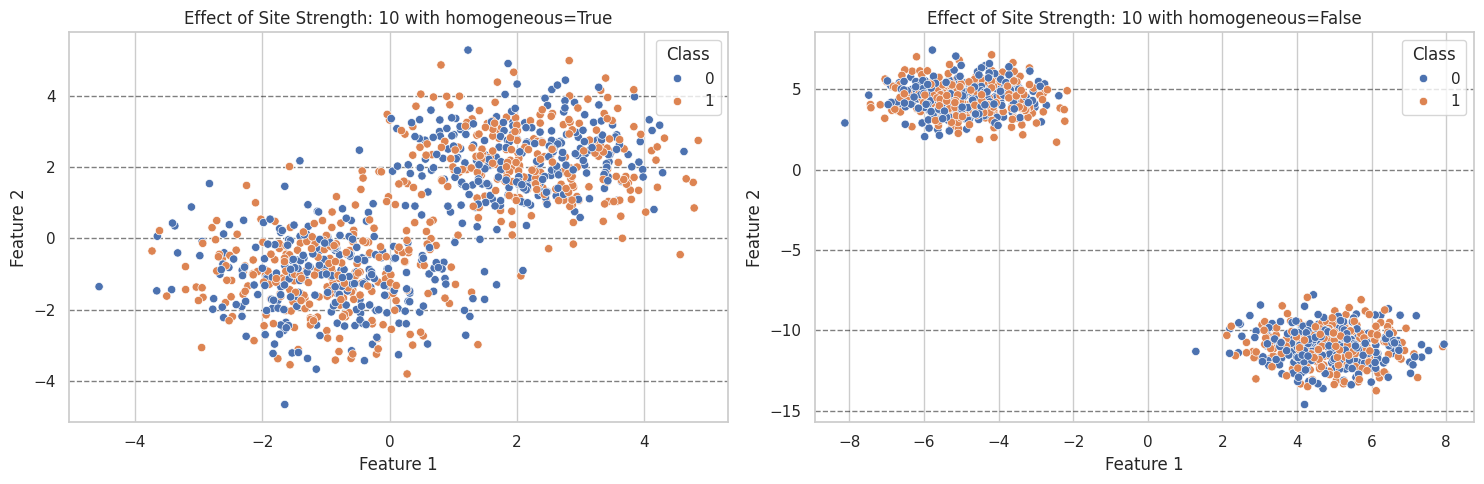

In [17]:
fig, axes = plt.subplots(1, 2, figsize=[15, 5])
verbosity("debug")
for idx, homogeneous in enumerate([True, False]):
    X, y, sites = make_multisite_classification(
        n_features=2,
        signal_strength=0,
        noise_strength=0,
        site_effect_strength=5,
        site_effect_homogeneous=homogeneous,
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Class", ax=axes[idx])
    axes[idx].set_title(f"Effect of Site Strength: {10} with homogeneous={homogeneous}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

​For the information printed, we can see that for `site_effect_homogeneous = True`, the Effect of Site (EoS) is **the same** for all features (in this case, we have 2 features).

In the first run, we have a strength of EoS of `[-1.08176037 -1.08176037]` for Site 1  and `[2.21054661 2.21054661]` for Site 2.

While of course different for each site, the simulated each features are **equally affected** by the EoS.

On the other hand, when using `site_effect_homogeneous = False`, the EoS strength for Site 1 is `[4.76512074 -11.03781863]`, and `[-4.79488122  4.36459174]` for Site 2.

In this case, we simulate that each feature is affected in a **different way** in each site.


### Noise effect

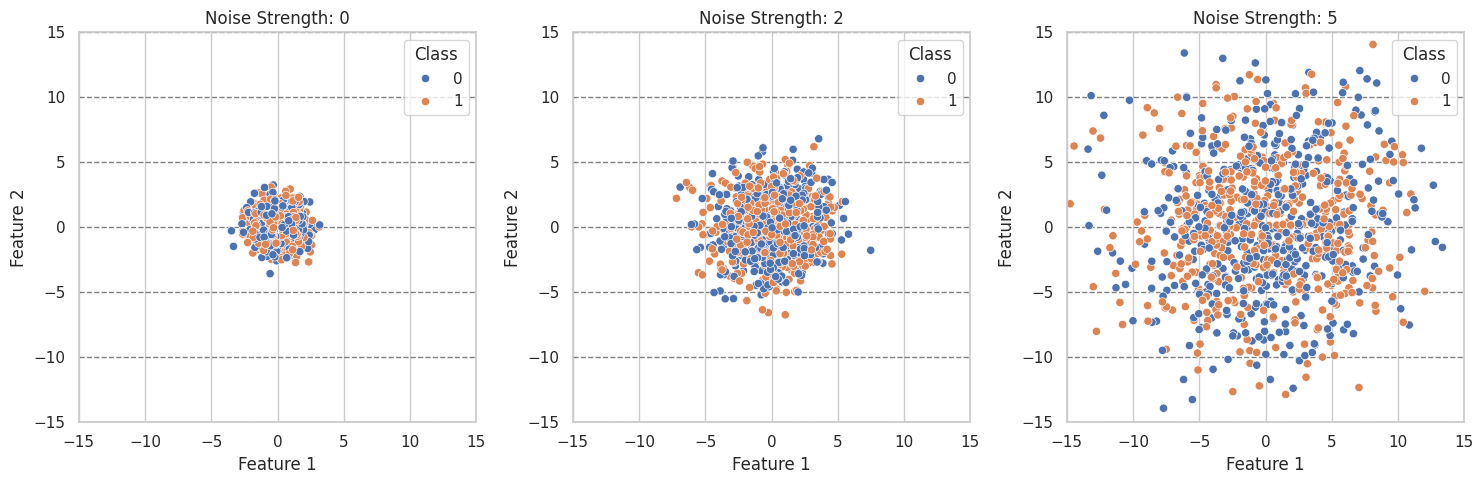

In [18]:
verbosity("warning")

fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, noise_st in enumerate([0, 2, 5]):
    X, y, sites = make_multisite_classification(
        n_features=2,
        signal_strength=0,
        noise_strength=noise_st,
        site_effect_strength=0,
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Class", ax=axes[idx])
    axes[idx].set_title(f"Noise Strength: {noise_st}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")
    axes[idx].set_xlim(-15, 15)
    axes[idx].set_ylim(-15, 15)

plt.tight_layout()